# Імпорт бібліотек

In [62]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Завантаження датасету

In [63]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


# Приклади

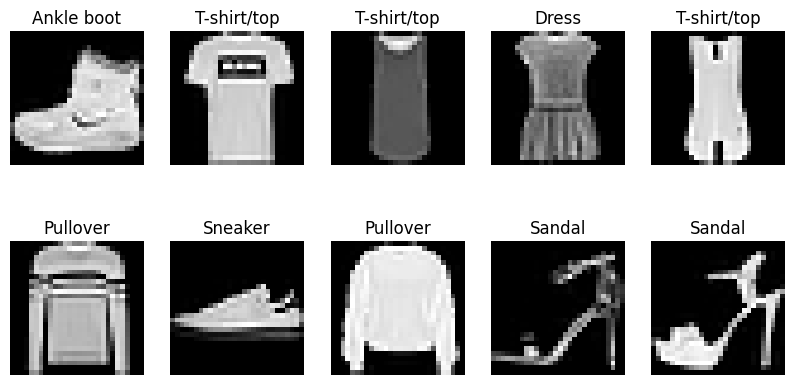

In [64]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.show()

# Підготовка даних

In [65]:
# Нормалізація
x_train = x_train / 255.0
x_test = x_test / 255.0

# Перетворення
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Створення архітектури

In [67]:
model = keras.Sequential([
    
    layers.Reshape((28, 28, 1), input_shape=(28,28)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation="softmax")
])

# Компіляція моделі

In [68]:
# Оптимізатор Adam

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)                  │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Навчання моделі

In [69]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.7934 - loss: 0.5667 - val_accuracy: 0.8480 - val_loss: 0.4061
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.8640 - loss: 0.3747 - val_accuracy: 0.8803 - val_loss: 0.3229
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8796 - loss: 0.3270 - val_accuracy: 0.8903 - val_loss: 0.2955
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.8914 - loss: 0.2940 - val_accuracy: 0.8997 - val_loss: 0.2749
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8987 - loss: 0.2708 - val_accuracy: 0.9007 - val_loss: 0.2682
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9060 - loss: 0.2539 - val_accuracy: 0.9031 - val_loss: 0.2625
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9132 - loss: 0.2355 - val_accuracy: 0.9087 - val_loss: 0.2496
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9174 - loss: 0.2190 - 

# Аналіз навчання

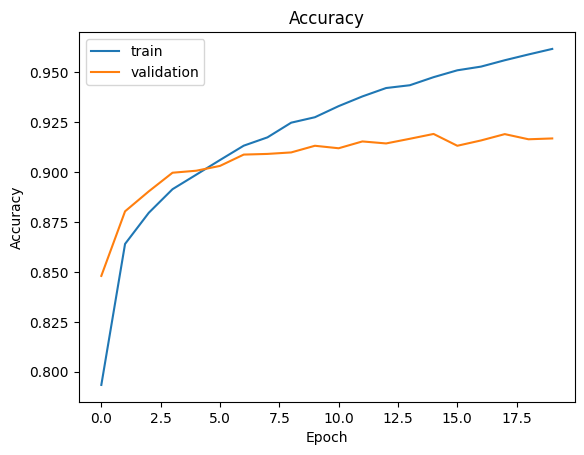

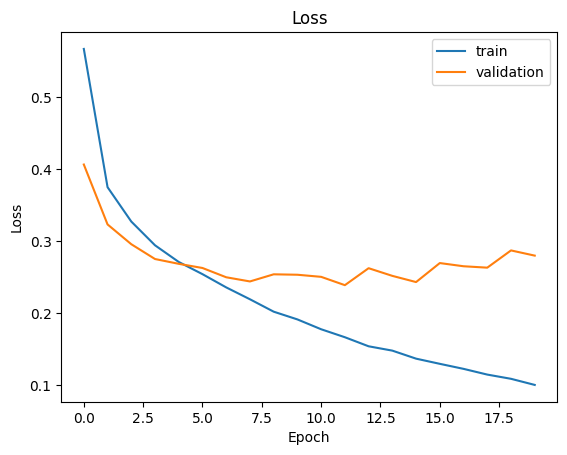

In [70]:
#Графік Accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["train","validation"])
plt.show()

#Графік loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["train","validation"])
plt.show()

# Перевірка на тестових даних

In [71]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9140 - loss: 0.3141
Test accuracy: 0.9139999747276306


# Матриця помилок

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


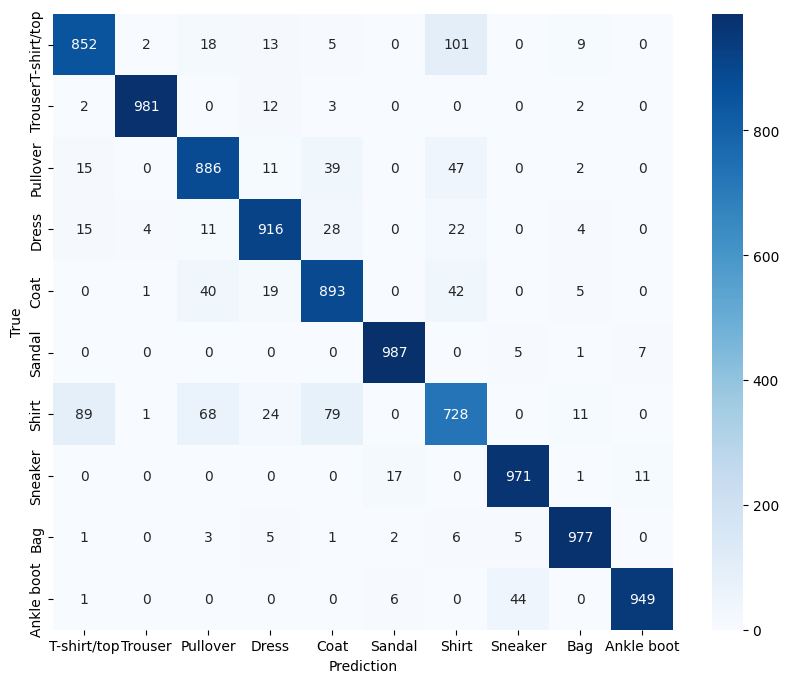

In [72]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediction")
plt.ylabel("True")
plt.show()

# Перевірка випадкових зображень

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


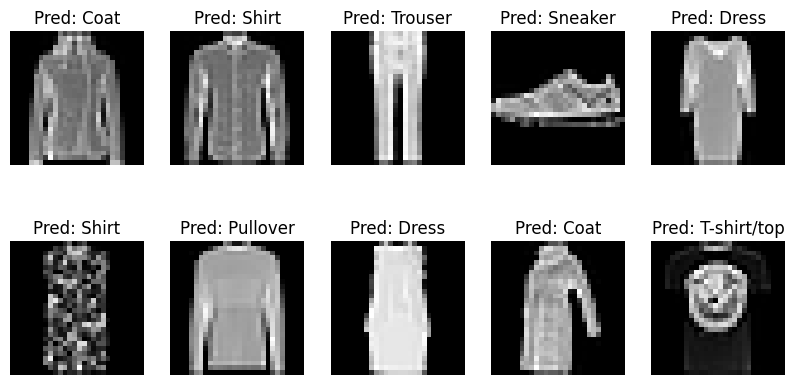

In [73]:
plt.figure(figsize=(10,5))

for i in range(10):
    idx = np.random.randint(0,len(x_test))
    prediction = model.predict(
        x_test[idx].reshape(1,28,28)
    )
    predicted_class = np.argmax(prediction)

    plt.subplot(2,5,i+1)

    plt.imshow(
        x_test[idx],
        cmap="gray"
    )

    plt.title(
        f"Pred: {class_names[predicted_class]}"
    )

    plt.axis("off")

plt.show()

# Висновки

In [ ]:
У роботі було створено нейронну мережу за допомогою Keras для класифікації зображень Fashion-MNIST.
Було протестовано різні параметри: кількість шарів, кількість нейронів, Dropout для боротьби з перенавчанням, оптимізатор Adam, кількість епох 
та batch size.
Побудована модель досягла точності близько 91-92% на тестовій вибірці.
За графіками навчання було перевірено відсутність значного перенавчання. Найбільші труднощі модель має при розпізнаванні схожих 
класів, наприклад Shirt та Coat.